# Blotto — entrega

Notebook de la entrega: corre los experimentos en Blotto (asignación de soldados sobre campos) con FP y RM (implementaciones del equipo, en `agents/`). Persiste `history` dicts en `data/blotto/`, guarda figuras en `images/blotto/`, y registra el progreso en `logs/blotto/Blotto.log`.

Las gráficas usan los helpers de `utils.plots` (compartidos por todos los notebooks del equipo). Cap visual: 1000 iter; el history completo (5000 iter) queda en cada `.pkl` por si después se quiere otra vista.

Se evalúan tres enfrentamientos:

- FictitiousPlay vs FictitiousPlay
- RegretMatching vs RegretMatching
- FictitiousPlay vs RegretMatching

## Setup

In [1]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Juego y agentes del equipo
from games.blotto import Blotto
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching

# Infraestructura compartida (utils/)
from utils.logger import get_logger
from utils.storage import cached, savefig
from utils.plots import (
    plot_policy_evolution,
    plot_distance_to_nash,
    plot_cumulative_average_reward,
    plot_cumulative_regret,
    plot_average_positive_regret,
    plot_instantaneous_vs_average_policy,
    plot_simplex_pairs,
)

# Helper para ejecutar y cachear corridas (importado desde utils/experiments.py)
from utils import experiments as exp

log = get_logger(notebook_name='Blotto2', game='blotto')

# Constantes del experimento
SOLDIERS = 6
BATTLEFIELDS = 3
ITERATIONS = 5000
MAX_ITER = 1000   # cap visual para las figuras (todas slicean a este horizonte)

_tmp_game = Blotto(S=SOLDIERS, N=BATTLEFIELDS)
ACTIONS = [np.array(move) for move in _tmp_game._moves]
ACTION_LABELS = [str(move.tolist()) for move in ACTIONS]
REFERENCE = np.full(len(ACTIONS), 1 / len(ACTIONS))  # referencia uniforme, no Nash analítico

log.info(f'Setup Blotto2 listo: acciones={ACTION_LABELS}')

2026-05-24 09:51:22 | INFO    | Setup Blotto2 listo: acciones=['[1, 1, 4]', '[1, 2, 3]', '[2, 2, 2]']


## FictitiousPlay vs FictitiousPlay

En Blotto no usamos la referencia uniforme como equilibrio teórico cerrado, sino como línea base visual. FP aprende frecuencias empíricas y juega mejores respuestas; por eso puede concentrarse rápidamente en alguna asignación si esa respuesta resulta estable frente al rival.

In [2]:
log.info('FP vs FP en Blotto — iniciando experimento')

# `initial` es dict[agent_id → ndarray]: conteo inicial de las acciones de cada
# OPONENTE. En Blotto usamos conteos uniformes como punto de partida neutral.
fp_initial = {
    'agent_0': np.ones(len(ACTIONS), dtype=int),
    'agent_1': np.ones(len(ACTIONS), dtype=int),
}
agent_pair_fp = [
    (FictitiousPlay, {'initial': fp_initial}),
    (FictitiousPlay, {'initial': fp_initial}),
]

history_fp = exp.cached_run('blotto_history_fp_vs_fp', Blotto(S=SOLDIERS, N=BATTLEFIELDS),
                            agent_pair_fp, iterations=ITERATIONS, seed=1)

log.info(f'FP vs FP: política final agent_0={history_fp["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 09:51:22 | INFO    | FP vs FP en Blotto — iniciando experimento
2026-05-24 09:51:22 | INFO    | FP vs FP: política final agent_0=[0. 0. 1.], agent_1=[0. 0. 1.]


### Evolución de la política

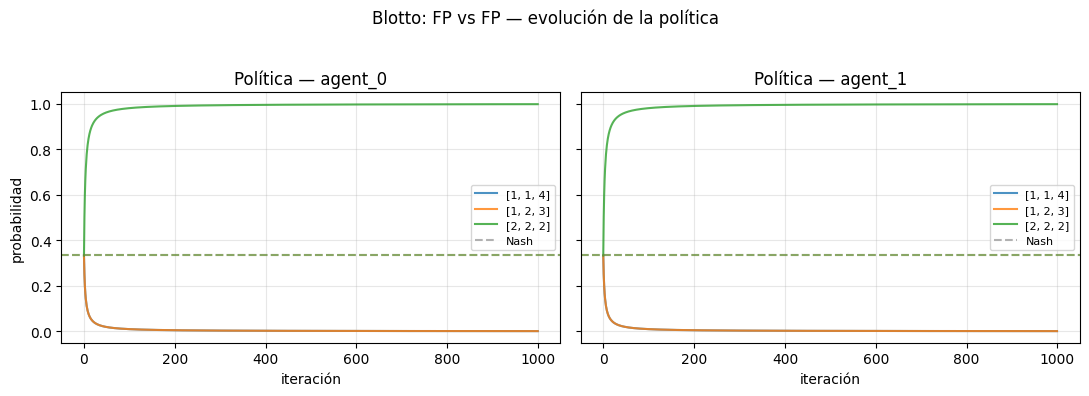

In [3]:
plot_policy_evolution(history_fp, action_labels=ACTION_LABELS, nash=REFERENCE,
                      title='Blotto: FP vs FP — evolución de la política',
                      save='blotto/policy_evolution_fp_vs_fp', max_iter=MAX_ITER)
plt.show()

### Distancia a la referencia uniforme

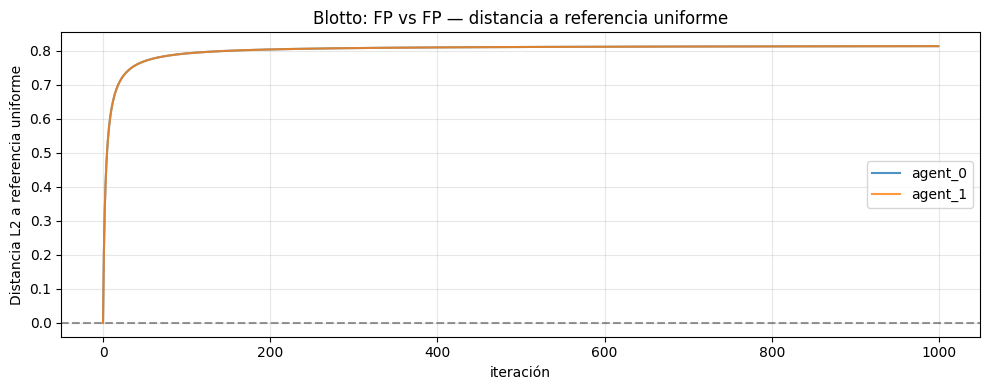

In [4]:
plot_distance_to_nash(history_fp, nash=REFERENCE, max_iter=MAX_ITER,
                      ylabel='Distancia L2 a referencia uniforme',
                      title='Blotto: FP vs FP — distancia a referencia uniforme',
                      save='blotto/distance_to_uniform_fp_vs_fp')
plt.show()

### Reward promedio acumulado

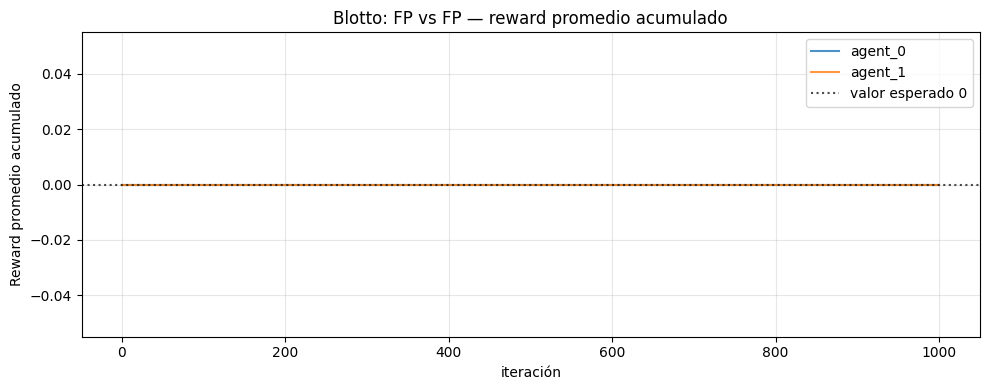

In [5]:
plot_cumulative_average_reward(history_fp, expected_value=0, max_iter=MAX_ITER,
                               title='Blotto: FP vs FP — reward promedio acumulado',
                               save='blotto/reward_cum_avg_fp_vs_fp')
plt.show()

### Trayectoria en el simplex

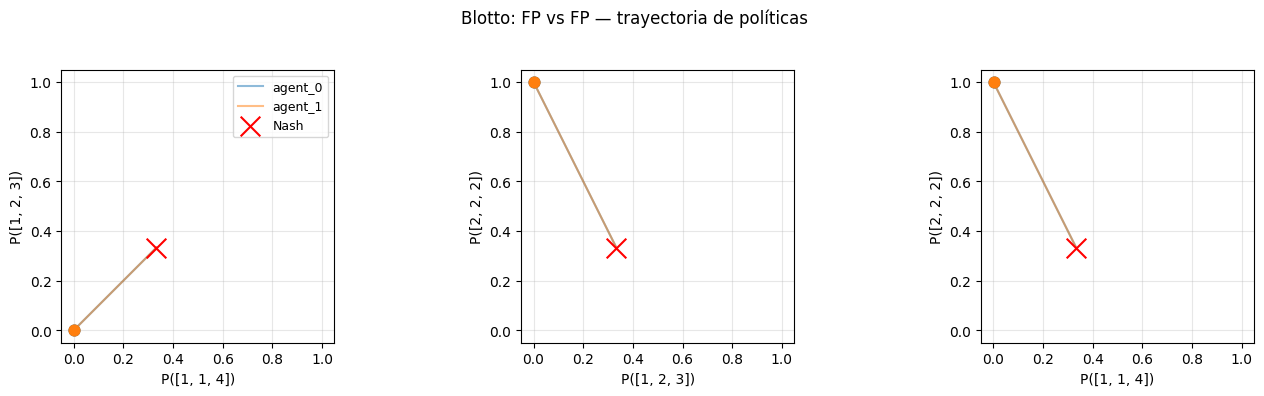

In [6]:
plot_simplex_pairs(history_fp['policy_history']['agent_0'],
                   history_fp['policy_history']['agent_1'],
                   nash=REFERENCE, action_labels=ACTION_LABELS,
                   title='Blotto: FP vs FP — trayectoria de políticas',
                   save='blotto/simplex_pairs_fp_vs_fp', max_iter=MAX_ITER)
plt.show()

## RegretMatching vs RegretMatching

RM construye una política promedio basada en regrets. En Blotto esto permite observar si el regret positivo promedio se reduce aunque la política no sea uniforme.

In [7]:
log.info('RM vs RM en Blotto — iniciando experimento')

agent_pair_rm = [(RegretMatching, {}), (RegretMatching, {})]
history_rm = exp.cached_run('blotto_history_rm_vs_rm', Blotto(S=SOLDIERS, N=BATTLEFIELDS),
                            agent_pair_rm, iterations=ITERATIONS, seed=1)

log.info(f'RM vs RM: política promedio final agent_0={history_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 09:51:23 | INFO    | RM vs RM en Blotto — iniciando experimento
2026-05-24 09:51:24 | INFO    | RM vs RM: política promedio final agent_0=[0. 0. 1.], agent_1=[0.  0.5 0.5]


### Política promedio aprendida

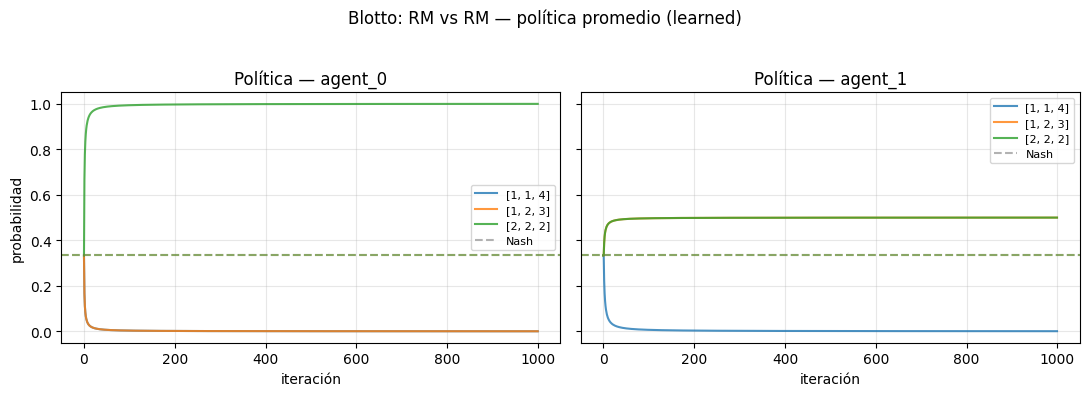

In [8]:
plot_policy_evolution(history_rm, action_labels=ACTION_LABELS, nash=REFERENCE,
                      title='Blotto: RM vs RM — política promedio (learned)',
                      save='blotto/policy_evolution_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Distancia a la referencia uniforme

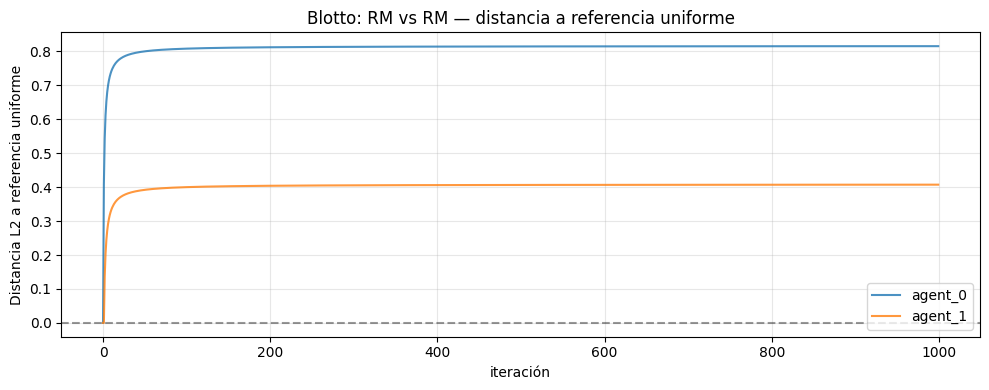

In [9]:
plot_distance_to_nash(history_rm, nash=REFERENCE, max_iter=MAX_ITER,
                      ylabel='Distancia L2 a referencia uniforme',
                      title='Blotto: RM vs RM — distancia a referencia uniforme',
                      save='blotto/distance_to_uniform_rm_vs_rm')
plt.show()

### Reward promedio acumulado

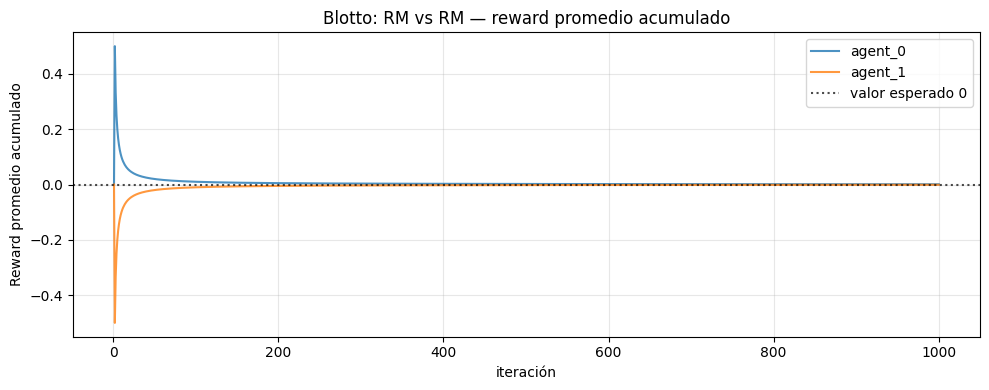

In [10]:
plot_cumulative_average_reward(history_rm, expected_value=0, max_iter=MAX_ITER,
                               title='Blotto: RM vs RM — reward promedio acumulado',
                               save='blotto/reward_cum_avg_rm_vs_rm')
plt.show()

### Regrets acumulados

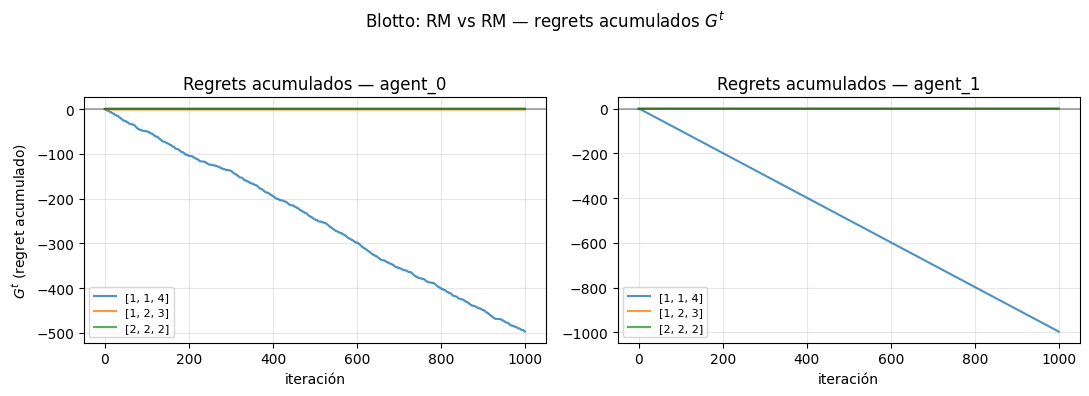

In [11]:
plot_cumulative_regret(history_rm, action_labels=ACTION_LABELS,
                       title='Blotto: RM vs RM — regrets acumulados $G^t$',
                       save='blotto/cum_regrets_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Regret promedio positivo / t

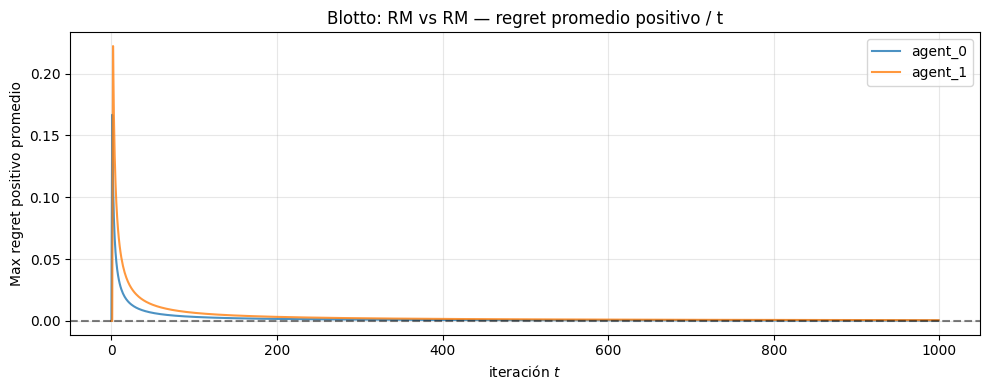

In [12]:
plot_average_positive_regret(history_rm,
                             title='Blotto: RM vs RM — regret promedio positivo / t',
                             save='blotto/avg_positive_regret_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Trayectoria en el simplex

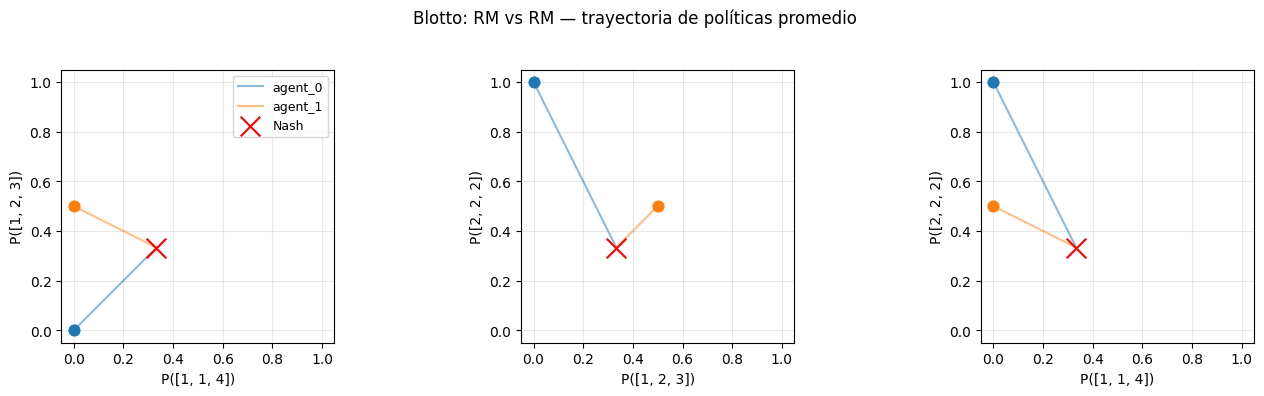

In [13]:
plot_simplex_pairs(history_rm['policy_history']['agent_0'],
                   history_rm['policy_history']['agent_1'],
                   nash=REFERENCE, action_labels=ACTION_LABELS,
                   title='Blotto: RM vs RM — trayectoria de políticas promedio',
                   save='blotto/simplex_pairs_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

## FictitiousPlay vs RegretMatching

Este escenario compara la respuesta greedy de FP contra la adaptación basada en regrets de RM.

In [14]:
log.info('FP vs RM en Blotto — iniciando experimento')

fp_initial = {
    'agent_0': np.ones(len(ACTIONS), dtype=int),
    'agent_1': np.ones(len(ACTIONS), dtype=int),
}
agent_pair_fp_rm = [
    (FictitiousPlay, {'initial': fp_initial}),
    (RegretMatching, {}),
]

history_fp_rm = exp.cached_run('blotto_history_fp_vs_rm', Blotto(S=SOLDIERS, N=BATTLEFIELDS),
                               agent_pair_fp_rm, iterations=ITERATIONS, seed=1)

log.info(f'FP vs RM: política final agent_0={history_fp_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 09:51:25 | INFO    | FP vs RM en Blotto — iniciando experimento
2026-05-24 09:51:26 | INFO    | FP vs RM: política final agent_0=[0. 0. 1.], agent_1=[0.  0.5 0.5]


### Políticas aprendidas (FP empírica + RM promedio)

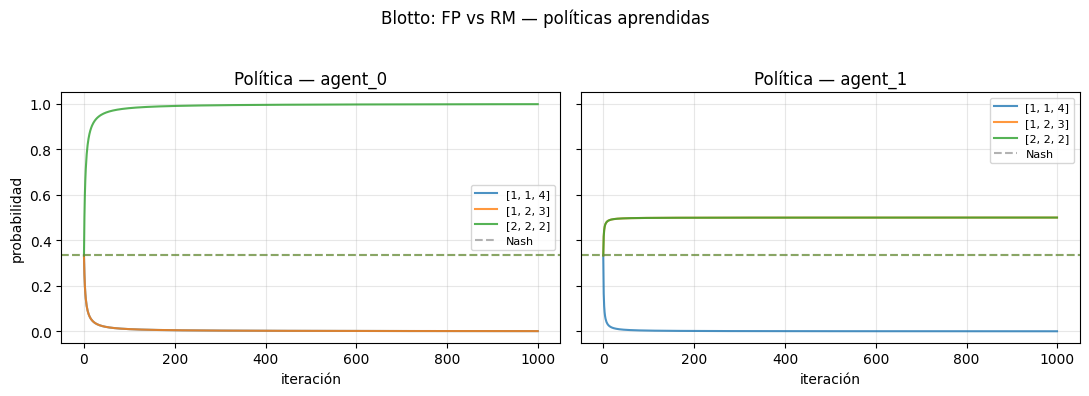

In [15]:
plot_policy_evolution(history_fp_rm, action_labels=ACTION_LABELS, nash=REFERENCE,
                      title='Blotto: FP vs RM — políticas aprendidas',
                      save='blotto/policy_evolution_fp_vs_rm', max_iter=MAX_ITER)
plt.show()

### Distancia a referencia uniforme + reward acumulado

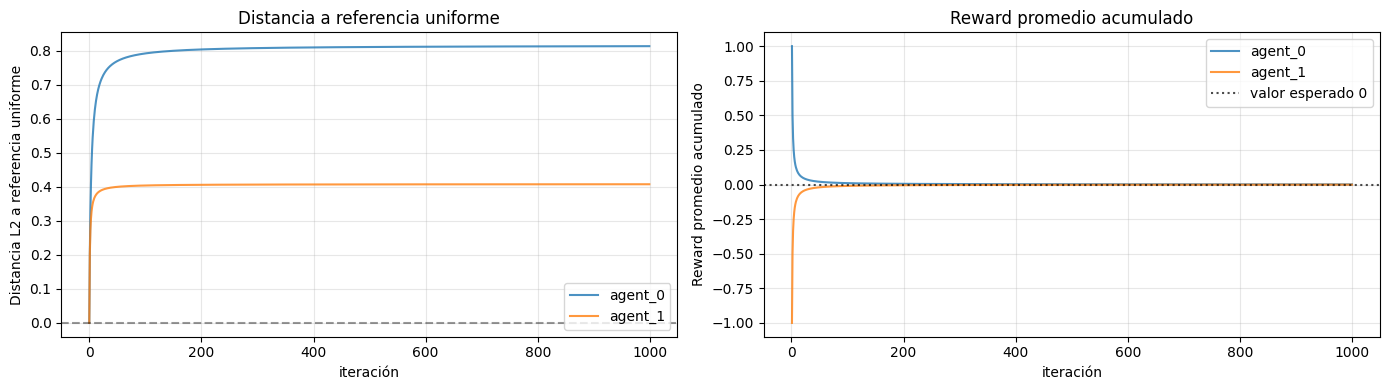

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rm, nash=REFERENCE, max_iter=MAX_ITER,
                      ylabel='Distancia L2 a referencia uniforme',
                      ax=axes[0], title='Distancia a referencia uniforme')
plot_cumulative_average_reward(history_fp_rm, expected_value=0, max_iter=MAX_ITER,
                               ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('blotto/distance_and_reward_fp_vs_rm')
plt.show()

### RM: política instantánea vs promedio temporal

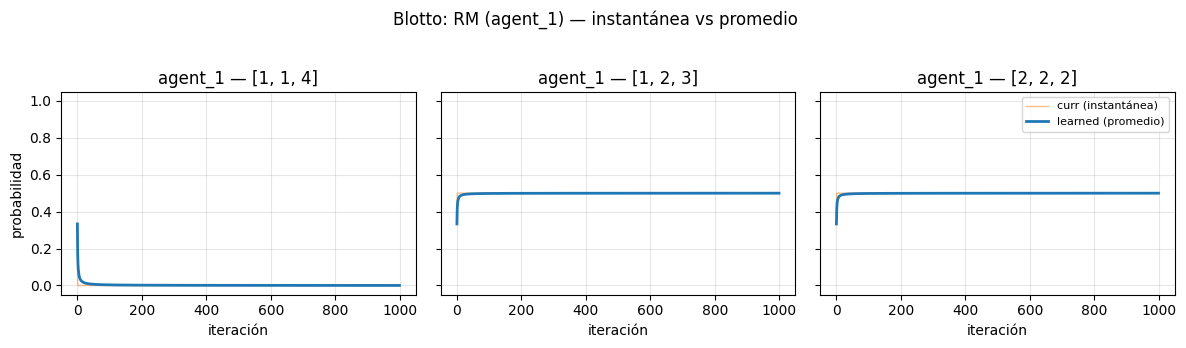

In [17]:
# Sólo aplica al agente RM (agent_1 en este pair)
plot_instantaneous_vs_average_policy(history_fp_rm, action_labels=ACTION_LABELS,
                                     agent='agent_1',
                                     title='Blotto: RM (agent_1) — instantánea vs promedio',
                                     save='blotto/curr_vs_avg_policy_rm_in_fp_vs_rm',
                                     max_iter=MAX_ITER)
plt.show()

### Trayectoria en el simplex

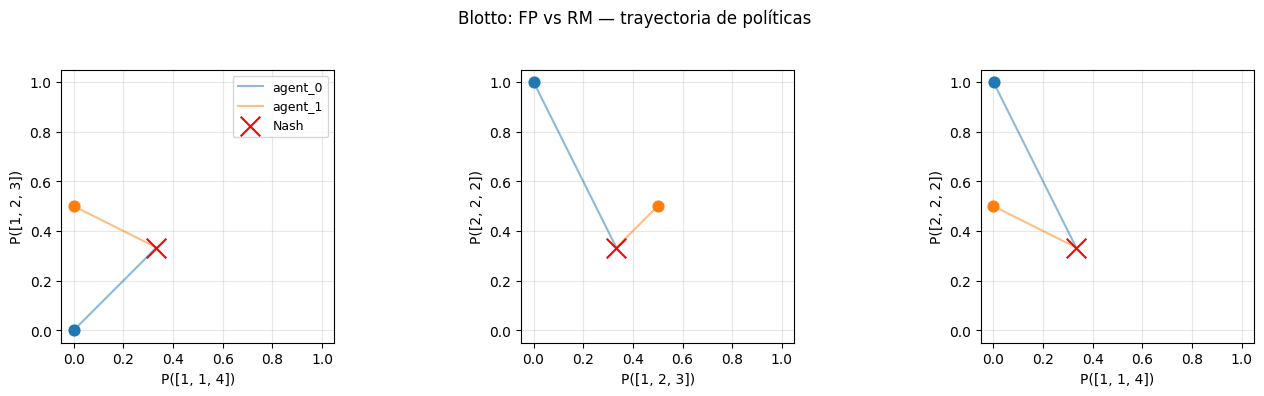

In [18]:
plot_simplex_pairs(history_fp_rm['policy_history']['agent_0'],
                   history_fp_rm['policy_history']['agent_1'],
                   nash=REFERENCE, action_labels=ACTION_LABELS,
                   title='Blotto: FP vs RM — trayectoria de políticas',
                   save='blotto/simplex_pairs_fp_vs_rm', max_iter=MAX_ITER)
plt.show()

---

**Notas**:

- Los `history` dicts quedan persistidos en `data/blotto/blotto_history_*.pkl`. Por defecto `exp.cached_run` re-ejecuta y sobrescribe (`force=True`); pasar `force=False` para reutilizar el cache cuando el experimento no cambió.
- Las figuras se guardan en `images/blotto/*.png`.
- El progreso del experimento queda en `logs/blotto/Blotto.log`.